In [1]:
# Platform-independent local workspace setup (no Google Drive / Colab dependency)
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
TOKENIZER_DIR = ARTIFACTS_DIR / "tokenizer"
MODEL_DIR = ARTIFACTS_DIR / "model_weights"
GENERATED_DIR = ARTIFACTS_DIR / "generated"

for folder in (DATA_ROOT, TOKENIZER_DIR, MODEL_DIR, GENERATED_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root:      {PROJECT_ROOT.resolve()}")
print(f"Data directory:   {DATA_ROOT.resolve()}")
print(f"Artifacts:        {ARTIFACTS_DIR.resolve()}")


Project root:      /content
Data directory:   /content/data
Artifacts:        /content/artifacts


In [2]:
# Install required packages into the current Python environment
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "miditok", "torchcodec"], check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'miditok', 'torchcodec'], returncode=0)

In [3]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["PYTHONHASHSEED"] = "42"

import random
import json
import math
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from miditok import REMI, TokenizerConfig
from miditok.pytorch_data import DatasetMIDI, DataCollator


In [4]:
SEED = 42
GENERATION_SEED = 42


def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)


set_global_seed(SEED)

print(f"Training seed: {SEED}")
print(f"Generation seed: {GENERATION_SEED}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Training seed: 42
Generation seed: 42
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [5]:
import subprocess

repo_url = "https://github.com/iamethanf20-hub/classical-piano-midi.git"
repo_dir = DATA_ROOT / "classical-piano-midi"

if (repo_dir / ".git").exists():
    print("Repository already exists; pulling latest changes...")
    subprocess.run(["git", "-C", str(repo_dir), "pull", "--ff-only"], check=True)
else:
    print("Cloning MIDI dataset from GitHub...")
    subprocess.run(["git", "clone", "--depth", "1", repo_url, str(repo_dir)], check=True)

data_dir = repo_dir

if not data_dir.exists():
    raise FileNotFoundError(f"Dataset folder does not exist: {data_dir}")

maindata = sorted(list(data_dir.rglob("*.mid")) + list(data_dir.rglob("*.midi")))

if len(maindata) == 0:
    raise ValueError(f"No MIDI files found inside: {data_dir}")

print(f"Found {len(maindata)} MIDI files from GitHub")
print("First 5 files:")
for path in maindata[:5]:
    print(" ", path)


Cloning MIDI dataset from GitHub...
Found 228 MIDI files from GitHub
First 5 files:
  /content/data/classical-piano-midi/amkamin.mid
  /content/data/classical-piano-midi/ballade2 (1).mid
  /content/data/classical-piano-midi/ballade3 (1).mid
  /content/data/classical-piano-midi/be-ps-29 (1).mid
  /content/data/classical-piano-midi/beethoveenrondo (1).mid


In [6]:
train_files, test_files = train_test_split(
    maindata,
    test_size=0.1,
    random_state=SEED,
)
train_files, val_files = train_test_split(
    train_files,
    test_size=0.111,
    random_state=SEED,
)

print(f"Train files: {len(train_files)}")
print(f"Val files:   {len(val_files)}")
print(f"Test files:  {len(test_files)}")

# Tokenizer
config = TokenizerConfig(
    num_velocities=16,
    use_chords=False,
    use_programs=True,
)
tokenizer = REMI(config)
tokenizer.train(vocab_size=len(tokenizer), files_paths=maindata)
tokenizer_path = TOKENIZER_DIR / "tokenizer.json"
tokenizer.save_params(tokenizer_path)
print(f"Tokenizer saved to: {tokenizer_path.resolve()}")

# Datasets
train_dataset = DatasetMIDI(
    files_paths=train_files,
    tokenizer=tokenizer,
    max_seq_len=2048,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)

val_dataset = DatasetMIDI(
    files_paths=val_files,
    tokenizer=tokenizer,
    max_seq_len=2048,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)

test_dataset = DatasetMIDI(
    files_paths=test_files,
    tokenizer=tokenizer,
    max_seq_len=2048,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)

collator = DataCollator(tokenizer.pad_token_id, copy_inputs_as_labels=True)

train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    collate_fn=collator,
    shuffle=True,
    generator=train_loader_generator,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    collate_fn=collator,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    collate_fn=collator,
    shuffle=False,
    num_workers=0,
)


Train files: 182
Val files:   23
Test files:  23
Tokenizer saved to: /content/artifacts/tokenizer/tokenizer.json


/usr/local/lib/python3.13/dist-packages/miditok/tokenizations/remi.py:88: UserWarning: Attribute controls are not compatible with 'config.one_token_stream_for_programs' and multi-vocabulary tokenizers. Disabling them from the config.
  super().__init__(tokenizer_config, params)
/tmp/ipykernel_4270/1207569759.py:23: UserWarning: miditok - tokenizer.train: `vocab_size` (397) need to be higher than the number of base tokens (397). Skipping tokenizer training.
  tokenizer.train(vocab_size=len(tokenizer), files_paths=maindata)
/tmp/ipykernel_4270/1207569759.py:25: UserWarning: miditok: The `save_params` method had been renamed `save`. It is now depreciated and will be removed in future updates.
  tokenizer.save_params(tokenizer_path)


In [7]:
class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_seq_len=2048):
        super().__init__()
        self.d_model = d_model
        inv_freq = 1.0 / (10000 ** (torch.arange(0, d_model, 2).float() / d_model))
        self.register_buffer('inv_freq', inv_freq)

        t = torch.arange(max_seq_len).type_as(self.inv_freq)
        freqs = torch.einsum('i,j->ij', t, self.inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        self.register_buffer('cos_cached', emb.cos()[None, None, :, :])
        self.register_buffer('sin_cached', emb.sin()[None, None, :, :])

    def rotate_half(self, x):
        x1, x2 = x[..., :x.shape[-1]//2], x[..., x.shape[-1]//2:]
        return torch.cat((-x2, x1), dim=-1)

    def forward(self, q, k):
        seq_len = q.shape[2]
        cos = self.cos_cached[:, :, :seq_len, :]
        sin = self.sin_cached[:, :, :seq_len, :]

        q_embed = (q * cos) + (self.rotate_half(q) * sin)
        k_embed = (k * cos) + (self.rotate_half(k) * sin)
        return q_embed, k_embed

In [8]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, max_seq_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.rope = RotaryPositionalEmbedding(self.head_dim, max_seq_len)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )

        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.shape

        residual = x
        x = self.ln1(x)

        qkv = self.qkv_proj(x)
        qkv = qkv.reshape(batch_size, seq_len, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q, k = self.rope(q, k)

        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            attn_scores = attn_scores + mask

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        attn_output = torch.matmul(attn_weights, v)
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.reshape(batch_size, seq_len, self.d_model)

        x = residual + self.dropout(self.out_proj(attn_output))

        residual = x
        x = self.ln2(x)
        x = residual + self.ff(x)

        return x

In [9]:
class AudioTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=768, n_heads=12, n_layers=8, max_seq_len=2048, dropout=0.1):
        super().__init__()
        self.vocab_size = vocab_size #encodec token size change
        #add self.num_codebooks, in example case 4
        self.d_model = d_model
        self.max_seq_len = max_seq_len

        self.embedding_layer = nn.Embedding(vocab_size, d_model) #self.embedding_layers=list of nn.embedding classes(nn.modulelist) dim = (4xvocab_sizexd_model)
        #embeddings inside module_list
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, max_seq_len, dropout)
            for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(d_model)
        self.output_layer = nn.Linear(d_model, vocab_size) #current matrix projection from d_model dimension space to vocab projection space
        #needs output for each codebook
        #output_layer = nn.module_list and nn.linear for each codebook

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x):
        batch_size, seq_len = x.shape
        #x = self.embedding_layer(x) for each codebook
        #compute self.embedding_layer for each codebook
        x = self.embedding_layer(x)
        #add all codebooks together and all resulting xs together
        x = self.dropout(x)

        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        mask = mask.unsqueeze(0).unsqueeze(0)

        for block in self.blocks:
            x = block(x, mask)

        x = self.ln_f(x)
        logits = self.output_layer(x) #run for each output layer

        return logits #seq_len x vocab_size

        #new logits tensor: seq_len x num_codebooks x vocab_size

In [10]:
class MusicalLoss(nn.Module):
    def __init__(
        self,
        tokenizer,
        lambda_continuity=0.1,
        lambda_rhythm=0.1,
        lambda_density=0.1,
        continuity_threshold=12.0,
        density_window=32,
        pad_token_id=None,
    ):
        super().__init__()
        self.tokenizer = tokenizer
        self.lambda_continuity = lambda_continuity
        self.lambda_rhythm = lambda_rhythm
        self.lambda_density = lambda_density
        self.continuity_threshold = float(continuity_threshold)
        self.density_window = int(density_window)
        self.pad_token_id = tokenizer.pad_token_id if pad_token_id is None else pad_token_id

        vocab_size = len(tokenizer)

        pitch_items = []
        duration_items = []
        velocity_items = []

        def parse_duration_token(token_str):
            """Convert MidiTok Duration values to beats.

            MidiTok commonly uses Duration_<beats>.<samples>.<resolution>, e.g.
            Duration_2.3.8 = 2 + 3/8 beats. A plain numeric value is also accepted.
            """
            value = token_str.split("_", 1)[1]
            parts = value.split(".")

            if len(parts) == 3:
                try:
                    beats = float(parts[0])
                    samples = float(parts[1])
                    resolution = float(parts[2])
                    if resolution <= 0:
                        raise ValueError("duration resolution must be > 0")
                    return beats + samples / resolution
                except ValueError:
                    pass

            return float(value)

        for token_str, token_id in tokenizer.vocab.items():
            if token_str.startswith("Pitch_"):
                pitch_items.append((int(token_id), float(token_str.split("_", 1)[1])))
            elif token_str.startswith("Duration_"):
                try:
                    duration_items.append((int(token_id), parse_duration_token(token_str)))
                except ValueError as exc:
                    raise ValueError(f"Could not parse duration token {token_str!r}") from exc
            elif token_str.startswith("Velocity_"):
                velocity_items.append((int(token_id), float(token_str.split("_", 1)[1])))

        pitch_items.sort(key=lambda x: x[0])
        duration_items.sort(key=lambda x: x[0])
        velocity_items.sort(key=lambda x: x[0])

        if not pitch_items:
            raise ValueError("No Pitch_ tokens were found in tokenizer.vocab")
        if not duration_items:
            raise ValueError("No Duration_ tokens were found in tokenizer.vocab")

        pitch_ids = torch.tensor([x[0] for x in pitch_items], dtype=torch.long)
        pitch_values = torch.tensor([x[1] for x in pitch_items], dtype=torch.float32)
        duration_ids = torch.tensor([x[0] for x in duration_items], dtype=torch.long)
        duration_values = torch.tensor([x[1] for x in duration_items], dtype=torch.float32)

        is_pitch_token = torch.zeros(vocab_size, dtype=torch.bool)
        is_duration_token = torch.zeros(vocab_size, dtype=torch.bool)
        duration_lookup = torch.zeros(vocab_size, dtype=torch.float32)

        is_pitch_token[pitch_ids] = True
        is_duration_token[duration_ids] = True
        duration_lookup[duration_ids] = duration_values

        # Pairwise differentiable interval-cost matrix between every pitch token.
        pitch_distance = torch.abs(pitch_values[:, None] - pitch_values[None, :])
        interval_cost = torch.relu(pitch_distance - self.continuity_threshold).pow(2)

        # Normalize by one octave squared so this auxiliary term remains on a
        # manageable scale relative to cross entropy.
        interval_cost = interval_cost / (12.0 ** 2)

        self.register_buffer("pitch_ids", pitch_ids)
        self.register_buffer("pitch_values", pitch_values)
        self.register_buffer("duration_ids", duration_ids)
        self.register_buffer("duration_values", duration_values)
        self.register_buffer("is_pitch_token", is_pitch_token)
        self.register_buffer("is_duration_token", is_duration_token)
        self.register_buffer("duration_lookup", duration_lookup)
        self.register_buffer("interval_cost", interval_cost)
        self.register_buffer("duration_scale", torch.tensor(max(duration_values.max().item(), 1e-6)))

        self.pitch_tokens = {token_id: int(value) for token_id, value in pitch_items}
        self.duration_tokens = {token_id: value for token_id, value in duration_items}
        self.velocity_tokens = {token_id: int(value) for token_id, value in velocity_items}

    def continuity_penalty(self, logits, labels):
        pitch_probs = torch.softmax(logits.index_select(-1, self.pitch_ids), dim=-1)
        pitch_positions = self.is_pitch_token[labels]

        sequence_losses = []
        for b in range(logits.size(0)):
            probs_b = pitch_probs[b][pitch_positions[b]]

            if probs_b.size(0) < 2:
                continue

            prev_probs = probs_b[:-1]
            next_probs = probs_b[1:]

            pair_cost = torch.einsum(
                "ni,ij,nj->n",
                prev_probs,
                self.interval_cost,
                next_probs,
            )
            sequence_losses.append(pair_cost.mean())

        if not sequence_losses:
            return logits.sum() * 0.0

        return torch.stack(sequence_losses).mean()

    def rhythm_penalty(self, logits, labels):
        duration_positions = self.is_duration_token[labels]
        if not duration_positions.any():
            return logits.sum() * 0.0

        duration_logits = logits.index_select(-1, self.duration_ids)
        duration_probs = torch.softmax(duration_logits, dim=-1)
        expected_duration = torch.sum(
            duration_probs * self.duration_values.view(1, 1, -1),
            dim=-1,
        )

        target_duration = self.duration_lookup[labels]

        pred = expected_duration[duration_positions] / self.duration_scale
        target = target_duration[duration_positions] / self.duration_scale

        return F.smooth_l1_loss(pred, target, beta=0.1)

    def density_penalty(self, logits, labels):
        valid = labels.ne(self.pad_token_id)
        target_pitch = self.is_pitch_token[labels].float()

        log_pitch_mass = torch.logsumexp(logits.index_select(-1, self.pitch_ids), dim=-1)
        log_total_mass = torch.logsumexp(logits, dim=-1)
        predicted_pitch_probability = torch.exp(log_pitch_mass - log_total_mass)

        predicted_pitch_probability = predicted_pitch_probability * valid.float()
        target_pitch = target_pitch * valid.float()

        seq_len = logits.size(1)
        window = min(self.density_window, seq_len)

        if window < 2:
            denom = valid.float().sum().clamp_min(1.0)
            return (((predicted_pitch_probability - target_pitch) ** 2) * valid.float()).sum() / denom

        stride = max(window // 2, 1)

        pred_sum = F.avg_pool1d(
            predicted_pitch_probability.unsqueeze(1),
            kernel_size=window,
            stride=stride,
        ).squeeze(1) * window

        target_sum = F.avg_pool1d(
            target_pitch.unsqueeze(1),
            kernel_size=window,
            stride=stride,
        ).squeeze(1) * window

        valid_count = F.avg_pool1d(
            valid.float().unsqueeze(1),
            kernel_size=window,
            stride=stride,
        ).squeeze(1) * window

        keep = valid_count > 0
        pred_density = pred_sum / valid_count.clamp_min(1.0)
        target_density = target_sum / valid_count.clamp_min(1.0)

        if not keep.any():
            return logits.sum() * 0.0

        return F.mse_loss(pred_density[keep], target_density[keep])

    def forward(self, logits, labels):
        cont_penalty = self.continuity_penalty(logits, labels)
        rhythm_penalty = self.rhythm_penalty(logits, labels)
        density_penalty = self.density_penalty(logits, labels)

        total_penalty = (
            self.lambda_continuity * cont_penalty
            + self.lambda_rhythm * rhythm_penalty
            + self.lambda_density * density_penalty
        )

        return total_penalty, {
            "continuity": cont_penalty,
            "rhythm": rhythm_penalty,
            "density": density_penalty,
        }


In [11]:
def create_continuation_examples(batch, phrase_length=512, pad_token_id=None, generator=None):
    input_ids = batch["input_ids"]
    target_len = phrase_length * 2

    if pad_token_id is None:
        pad_token_id = tokenizer.pad_token_id

    augmented_sequences = []

    for seq in input_ids:
        valid_len = int((seq != pad_token_id).sum().item())

        if valid_len > target_len:
            max_start = valid_len - target_len
            start_idx = torch.randint(
                0,
                max_start + 1,
                (1,),
                generator=generator,
            ).item()
            selected = seq[start_idx:start_idx + target_len]
        else:
            selected = seq[:target_len]

        if selected.numel() < target_len:
            selected = F.pad(
                selected,
                (0, target_len - selected.numel()),
                value=pad_token_id,
            )

        augmented_sequences.append(selected)

    return {"input_ids": torch.stack(augmented_sequences)}


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_global_seed(SEED)

model = AudioTransformer(
    vocab_size=len(tokenizer),
    d_model=768,
    n_heads=12,
    n_layers=8,
    max_seq_len=2048,
    dropout=0.1,
).to(device)

print(f"Model initialized deterministically on: {device}")


Model initialized deterministically on: cuda


MusicalLoss token maps: 89 pitch, 64 duration, 16 velocity
Example duration tokens: [(110, 0.125), (111, 0.25), (112, 0.375), (113, 0.5), (114, 0.625), (115, 0.75), (116, 0.875), (117, 1.0)]
Epoch 1/25
  Train - Loss: 3.1997 (CE: 3.1482, Music: 0.0514)
          Cont: 0.4855, Rhythm: 0.0280, Density: 0.0008
  Val   - Loss: 2.5374 (CE: 2.5166, Music: 0.0208)
          Cont: 0.1935, Rhythm: 0.0147, Density: 0.0000  ✓ Best saved!
Epoch 2/25
  Train - Loss: 2.3003 (CE: 2.2794, Music: 0.0208)
          Cont: 0.1945, Rhythm: 0.0119, Density: 0.0018
  Val   - Loss: 2.3692 (CE: 2.3494, Music: 0.0198)
          Cont: 0.1836, Rhythm: 0.0141, Density: 0.0000  ✓ Best saved!
Epoch 3/25
  Train - Loss: 2.1407 (CE: 2.1187, Music: 0.0220)
          Cont: 0.2078, Rhythm: 0.0114, Density: 0.0005
  Val   - Loss: 2.1741 (CE: 2.1517, Music: 0.0224)
          Cont: 0.2100, Rhythm: 0.0137, Density: 0.0000  ✓ Best saved!
Epoch 4/25
  Train - Loss: 2.0080 (CE: 1.9868, Music: 0.0212)
          Cont: 0.2008, Rhy

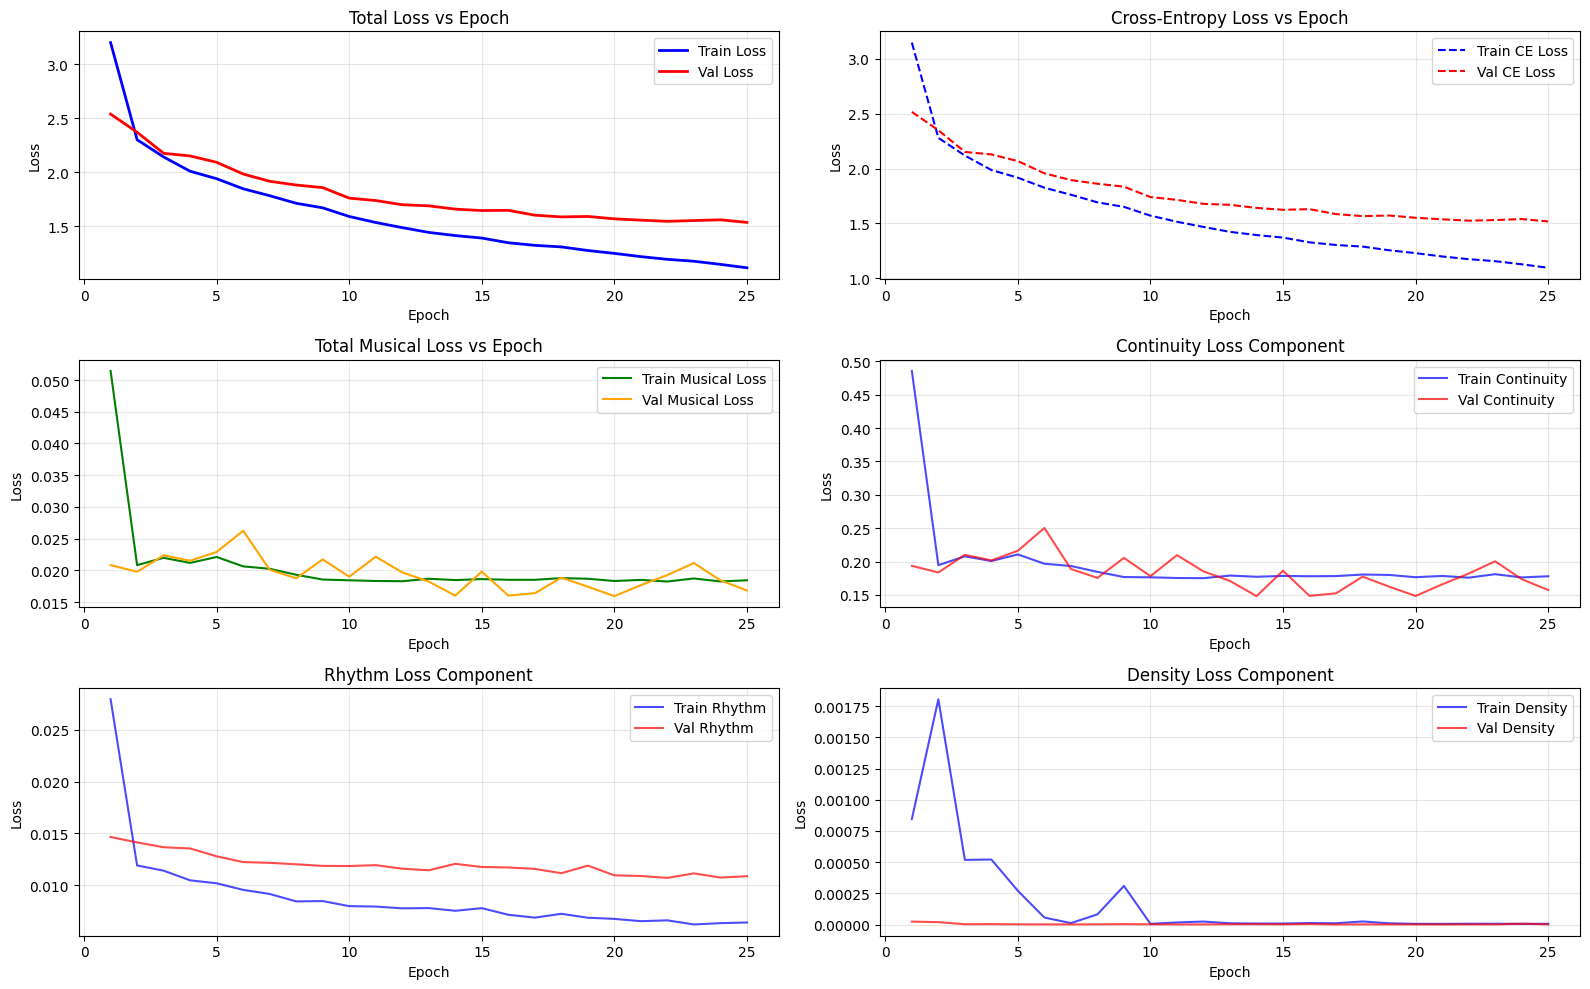

Loss plot saved to: /content/artifacts/training_losses_seed42.png

Evaluating on TEST SET (final evaluation)

FINAL TEST RESULTS:
  Test Loss: 1.4386
  Test CE Loss: 1.4212
  Test Musical Loss: 0.0174
    - Continuity: 0.1671
    - Rhythm: 0.0069
    - Density: 0.0004


In [13]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01,
    betas=(0.9, 0.95),
)

pad_token_id = tokenizer.pad_token_id
ce_criterion = nn.CrossEntropyLoss(ignore_index=pad_token_id)

musical_loss = MusicalLoss(
    tokenizer,
    lambda_continuity=0.1,
    lambda_rhythm=0.1,
    lambda_density=0.1,
    continuity_threshold=12.0,
    density_window=32,
    pad_token_id=pad_token_id,
).to(device)

print(
    f"MusicalLoss token maps: "
    f"{len(musical_loss.pitch_ids)} pitch, "
    f"{len(musical_loss.duration_ids)} duration, "
    f"{len(musical_loss.velocity_tokens)} velocity"
)
print("Example duration tokens:", list(musical_loss.duration_tokens.items())[:8])

augmentation_generator = torch.Generator()
augmentation_generator.manual_seed(SEED + 1)

train_losses = []
val_losses = []
train_ce_losses = []
val_ce_losses = []
train_musical_losses = []
val_musical_losses = []
train_cont_losses = []
train_rhythm_losses = []
train_density_losses = []
val_cont_losses = []
val_rhythm_losses = []
val_density_losses = []

num_epochs = 25
best_val_loss = float("inf")
patience = 0
patience_limit = 20

use_phrase_augmentation = True
phrase_length = 512

model_dir = MODEL_DIR
model_dir.mkdir(parents=True, exist_ok=True)

best_model_path = model_dir / f"transformer_weights_main_seed{SEED}_best.pth"
final_model_path = model_dir / f"transformer_weights_main_seed{SEED}_final.pth"

for epoch in range(num_epochs):
    model.train()
    train_total_loss = 0.0
    train_total_ce_loss = 0.0
    train_total_musical_loss = 0.0
    train_total_cont = 0.0
    train_total_rhythm = 0.0
    train_total_density = 0.0

    for batch_idx, batch in enumerate(train_loader):
        if use_phrase_augmentation:
            do_augment = torch.rand((), generator=augmentation_generator).item() > 0.5
            if do_augment:
                batch = create_continuation_examples(
                    batch,
                    phrase_length=phrase_length,
                    pad_token_id=pad_token_id,
                    generator=augmentation_generator,
                )

        full_seq = batch["input_ids"].to(device)
        input_ids = full_seq[:, :-1]
        labels = full_seq[:, 1:]

        optimizer.zero_grad(set_to_none=True)
        logits = model(input_ids)

        ce_loss = ce_criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        music_loss, music_components = musical_loss(logits, labels)
        total_loss = ce_loss + music_loss

        if not torch.isfinite(total_loss):
            raise RuntimeError(
                f"Non-finite loss at epoch {epoch + 1}, batch {batch_idx}: "
                f"CE={ce_loss.item()}, music={music_loss.item()}"
            )

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_total_loss += total_loss.item()
        train_total_ce_loss += ce_loss.item()
        train_total_musical_loss += music_loss.item()
        train_total_cont += music_components["continuity"].item()
        train_total_rhythm += music_components["rhythm"].item()
        train_total_density += music_components["density"].item()

    avg_train_loss = train_total_loss / len(train_loader)
    avg_train_ce = train_total_ce_loss / len(train_loader)
    avg_train_music = train_total_musical_loss / len(train_loader)
    avg_train_cont = train_total_cont / len(train_loader)
    avg_train_rhythm = train_total_rhythm / len(train_loader)
    avg_train_density = train_total_density / len(train_loader)

    model.eval()
    val_total_loss = 0.0
    val_total_ce_loss = 0.0
    val_total_musical_loss = 0.0
    val_total_cont = 0.0
    val_total_rhythm = 0.0
    val_total_density = 0.0

    with torch.no_grad():
        for batch in val_loader:
            full_seq = batch["input_ids"].to(device)
            input_ids = full_seq[:, :-1]
            labels = full_seq[:, 1:]

            logits = model(input_ids)

            ce_loss = ce_criterion(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1),
            )
            music_loss, music_components = musical_loss(logits, labels)
            total_loss = ce_loss + music_loss

            val_total_loss += total_loss.item()
            val_total_ce_loss += ce_loss.item()
            val_total_musical_loss += music_loss.item()
            val_total_cont += music_components["continuity"].item()
            val_total_rhythm += music_components["rhythm"].item()
            val_total_density += music_components["density"].item()

    avg_val_loss = val_total_loss / len(val_loader)
    avg_val_ce = val_total_ce_loss / len(val_loader)
    avg_val_music = val_total_musical_loss / len(val_loader)
    avg_val_cont = val_total_cont / len(val_loader)
    avg_val_rhythm = val_total_rhythm / len(val_loader)
    avg_val_density = val_total_density / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_ce_losses.append(avg_train_ce)
    val_ce_losses.append(avg_val_ce)
    train_musical_losses.append(avg_train_music)
    val_musical_losses.append(avg_val_music)
    train_cont_losses.append(avg_train_cont)
    train_rhythm_losses.append(avg_train_rhythm)
    train_density_losses.append(avg_train_density)
    val_cont_losses.append(avg_val_cont)
    val_rhythm_losses.append(avg_val_rhythm)
    val_density_losses.append(avg_val_density)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(
        f"  Train - Loss: {avg_train_loss:.4f} "
        f"(CE: {avg_train_ce:.4f}, Music: {avg_train_music:.4f})"
    )
    print(
        f"          Cont: {avg_train_cont:.4f}, "
        f"Rhythm: {avg_train_rhythm:.4f}, "
        f"Density: {avg_train_density:.4f}"
    )
    print(
        f"  Val   - Loss: {avg_val_loss:.4f} "
        f"(CE: {avg_val_ce:.4f}, Music: {avg_val_music:.4f})"
    )
    print(
        f"          Cont: {avg_val_cont:.4f}, "
        f"Rhythm: {avg_val_rhythm:.4f}, "
        f"Density: {avg_val_density:.4f}",
        end=""
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print("  ✓ Best saved!")
        patience = 0
    else:
        patience += 1
        print()

    if patience >= patience_limit:
        print(f"\nNo improvement for {patience_limit} epochs. Stopping early.")
        break

torch.save(model.state_dict(), final_model_path)
print(f"Training complete.\nBest:  {best_model_path}\nFinal: {final_model_path}")

history_path = ARTIFACTS_DIR / f"training_history_seed{SEED}.npz"
np.savez(
    history_path,
    train_loss=np.asarray(train_losses),
    val_loss=np.asarray(val_losses),
    train_ce=np.asarray(train_ce_losses),
    val_ce=np.asarray(val_ce_losses),
    train_music=np.asarray(train_musical_losses),
    val_music=np.asarray(val_musical_losses),
    train_cont=np.asarray(train_cont_losses),
    val_cont=np.asarray(val_cont_losses),
    train_rhythm=np.asarray(train_rhythm_losses),
    val_rhythm=np.asarray(val_rhythm_losses),
    train_density=np.asarray(train_density_losses),
    val_density=np.asarray(val_density_losses),
)
print(f"Training history saved to: {history_path}")

epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(16, 10))

plt.subplot(3, 2, 1)
plt.plot(epochs_range, train_losses, "b-", label="Train Loss", linewidth=2)
plt.plot(epochs_range, val_losses, "r-", label="Val Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 2)
plt.plot(epochs_range, train_ce_losses, "b--", label="Train CE Loss", linewidth=1.5)
plt.plot(epochs_range, val_ce_losses, "r--", label="Val CE Loss", linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cross-Entropy Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 3)
plt.plot(epochs_range, train_musical_losses, "g-", label="Train Musical Loss", linewidth=1.5)
plt.plot(epochs_range, val_musical_losses, "orange", label="Val Musical Loss", linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total Musical Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 4)
plt.plot(epochs_range, train_cont_losses, "b-", label="Train Continuity", linewidth=1.5, alpha=0.7)
plt.plot(epochs_range, val_cont_losses, "r-", label="Val Continuity", linewidth=1.5, alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Continuity Loss Component")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 5)
plt.plot(epochs_range, train_rhythm_losses, "b-", label="Train Rhythm", linewidth=1.5, alpha=0.7)
plt.plot(epochs_range, val_rhythm_losses, "r-", label="Val Rhythm", linewidth=1.5, alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Rhythm Loss Component")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 6)
plt.plot(epochs_range, train_density_losses, "b-", label="Train Density", linewidth=1.5, alpha=0.7)
plt.plot(epochs_range, val_density_losses, "r-", label="Val Density", linewidth=1.5, alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Density Loss Component")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = ARTIFACTS_DIR / f"training_losses_seed{SEED}.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Loss plot saved to: {plot_path}")

print("\n" + "=" * 50)
print("Evaluating on TEST SET (final evaluation)")
print("=" * 50)

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_total_loss = 0.0
test_total_ce_loss = 0.0
test_total_musical_loss = 0.0
test_total_cont = 0.0
test_total_rhythm = 0.0
test_total_density = 0.0

with torch.no_grad():
    for batch in test_loader:
        full_seq = batch["input_ids"].to(device)
        input_ids = full_seq[:, :-1]
        labels = full_seq[:, 1:]

        logits = model(input_ids)

        ce_loss = ce_criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        music_loss, music_components = musical_loss(logits, labels)
        total_loss = ce_loss + music_loss

        test_total_loss += total_loss.item()
        test_total_ce_loss += ce_loss.item()
        test_total_musical_loss += music_loss.item()
        test_total_cont += music_components["continuity"].item()
        test_total_rhythm += music_components["rhythm"].item()
        test_total_density += music_components["density"].item()

avg_test_loss = test_total_loss / len(test_loader)
avg_test_ce = test_total_ce_loss / len(test_loader)
avg_test_music = test_total_musical_loss / len(test_loader)
avg_test_cont = test_total_cont / len(test_loader)
avg_test_rhythm = test_total_rhythm / len(test_loader)
avg_test_density = test_total_density / len(test_loader)

print("\nFINAL TEST RESULTS:")
print(f"  Test Loss: {avg_test_loss:.4f}")
print(f"  Test CE Loss: {avg_test_ce:.4f}")
print(f"  Test Musical Loss: {avg_test_music:.4f}")
print(f"    - Continuity: {avg_test_cont:.4f}")
print(f"    - Rhythm: {avg_test_rhythm:.4f}")
print(f"    - Density: {avg_test_density:.4f}")


In [14]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

max_length = 1000
temperature = 0.75
top_p = 0.90

prompt_length = 256
prompt_index = 121

if prompt_index >= len(train_loader.dataset):
    raise IndexError(
        f"prompt_index={prompt_index} but train dataset has only "
        f"{len(train_loader.dataset)} items"
    )

generated = train_loader.dataset[prompt_index]["input_ids"][:prompt_length].tolist()

generator_device = "cuda" if device.type == "cuda" else "cpu"
generation_generator = torch.Generator(device=generator_device)
generation_generator.manual_seed(GENERATION_SEED)

print(
    f"Starting top-p generation with {prompt_length}-token prompt, "
    f"prompt_index={prompt_index}, seed={GENERATION_SEED}..."
)

with torch.no_grad():
    for i in range(max_length):
        input_ids = torch.tensor(
            [generated],
            dtype=torch.long,
            device=device
        )

        logits = model(input_ids)
        next_token_logits = logits[0, -1, :] / temperature

        # top-p sampling
        sorted_logits, sorted_indices = torch.sort(
            next_token_logits,
            descending=True
        )

        sorted_probs = torch.softmax(sorted_logits, dim=-1)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

        sorted_indices_to_remove = cumulative_probs > top_p

        sorted_indices_to_remove[1:] = (
            sorted_indices_to_remove[:-1].clone()
        )
        sorted_indices_to_remove[0] = False

        indices_to_remove = sorted_indices[
            sorted_indices_to_remove
        ]

        next_token_logits[indices_to_remove] = float("-inf")

        probs = torch.softmax(next_token_logits, dim=-1)

        next_token = torch.multinomial(
            probs,
            num_samples=1,
            generator=generation_generator,
        ).item()

        generated.append(next_token)

        if (i + 1) % 100 == 0:
            print(f"Generated {i + 1}/{max_length} new tokens")

        if next_token == tokenizer["EOS_None"]:
            print(f"EOS reached after {i + 1} new tokens")
            break

print(f"Generated {len(generated)} total tokens")

generated_midi = tokenizer.decode(generated)

output_filename = GENERATED_DIR / f"generated_topp_seed{GENERATION_SEED}.mid"

generated_midi.dump_midi(output_filename)

token_output = GENERATED_DIR / f"generated_topp_seed{GENERATION_SEED}_tokens.npy"

np.save(
    token_output,
    np.asarray(generated, dtype=np.int64)
)

print(f"MIDI saved to:   {output_filename}")
print(f"Tokens saved to: {token_output}")

Starting top-p generation with 256-token prompt, prompt_index=121, seed=42...
Generated 100/1000 new tokens
Generated 200/1000 new tokens
Generated 300/1000 new tokens
Generated 400/1000 new tokens
Generated 500/1000 new tokens
Generated 600/1000 new tokens
Generated 700/1000 new tokens
Generated 800/1000 new tokens
Generated 900/1000 new tokens
Generated 1000/1000 new tokens
Generated 1256 total tokens
MIDI saved to:   /content/artifacts/generated/generated_topp_seed42.mid
Tokens saved to: /content/artifacts/generated/generated_topp_seed42_tokens.npy
